# Synthetic-100 regression: RBF MiSTIC at rank weight 0.75

This notebook reevaluates the best rank weight from the linear-kernel sweep
using an RBF kernel. It retains the identical synthetic data, fixed blind set,
ten inner seeds, 20 members, forward-knee search, `addition_factor=0.1`,
`max_features=20`, separate feature sets and parameters, no per-step tuning,
and final knee retuning.

Unlike the linear model, the RBF MiSTIC parameter grid tunes C, gamma, and
epsilon. Existing linear-MiSTIC, RBF-weight-0.90, and sklearn results are loaded
only after the new fits for comparison.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.datasets import make_regression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svr, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))
DATA_SEED = 2026
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
MEMBER_COUNTS = [5, 10, 20]
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.90
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]
EPSILON_VALUES = [0.05, 0.1, 0.2]

# Start with 10 informative plus 80 independent noise predictors. Insert 10
# noisy linear combinations of the informative block as redundant signal.
base_X, y_values, coefficients = make_regression(
    n_samples=N_SAMPLES, n_features=90, n_informative=N_INFORMATIVE,
    noise=20.0, shuffle=False, random_state=DATA_SEED, coef=True,
)
rng = np.random.default_rng(DATA_SEED)
mixing = rng.normal(size=(N_INFORMATIVE, N_REDUNDANT))
redundant = base_X[:, :N_INFORMATIVE] @ mixing
redundant += rng.normal(scale=0.10 * redundant.std(axis=0), size=redundant.shape)
X_values = np.column_stack([base_X[:, :N_INFORMATIVE], redundant, base_X[:, N_INFORMATIVE:]])
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="target")

X_train, X_blind, y_train_raw, y_blind_raw = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=BLIND_SET_SEED,
)
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(ddof=0)
y_train = (y_train_raw - y_mean) / y_scale
y_blind = (y_blind_raw - y_mean) / y_scale
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")
print(f"Training target mean={y_train.mean():.3g}, SD={y_train.std(ddof=0):.3g}")


Training rows: 375; fixed blind rows: 125
Training target mean=0, SD=1


In [3]:
def metric_row(y_true, predictions):
    r = pearsonr(y_true, predictions).statistic
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
        "pearson_r2": r * r,
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def sklearn_grid(seed):
    return GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))]),
        {"svr__C": C_VALUES, "svr__gamma": GAMMA_VALUES,
         "svr__epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )


def fit_sklearn(features, seed):
    features = np.asarray(features, dtype=int)
    return sklearn_grid(seed).fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed, num_models, rank_weight):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(X_scaled, np.asarray(y_train), num_feature_medoids=20,
                   ensemble_validation_size=0.0)
    splitter = ShuffleSplit(n_splits=num_models,
                            test_size=INNER_VALIDATION_SIZE,
                            random_state=seed)
    generated = list(splitter.split(X_scaled, y_train))
    splits.train = [train for train, _ in generated]
    splits.test = [test for _, test in generated]
    splits.type = "regression_shuffle_split"
    ensemble = svmSet(
        SVR(kernel="precomputed"), splits,
        score_method=score_svr(weight=0.0).score,
        kernel=kernelWrapper(type="rbf"),
        separate_feature_sets=True, separate_parameters=True,
    )
    grid = [
        paramSet(model={"C": c, "epsilon": epsilon}, kernel={"gamma": gamma})
        for c in C_VALUES for gamma in GAMMA_VALUES for epsilon in EPSILON_VALUES
    ]
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=rank_weight).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed, associated_members=0):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn(features, seed)
    predictions = model.predict(X_blind.iloc[:, features])
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "associated_mistic_members": associated_members,
        "knee_feature_count": np.nan, "mean_member_features": np.nan,
        "num_unified_features": len(features),
        "top20_signal_recall": recall, "top20_signal_precision": precision,
        "member_disagreement": 0.0, "cv_best_score": model.best_score_,
        **metric_row(y_blind, predictions),
    }


## Run RBF MiSTIC at weight 0.75

All ten runs use the same inner seeds and blind observations as the previous
benchmarks, enabling paired comparisons.


In [4]:
RANK_WEIGHT_TEST = 0.75
NUM_MODELS = 20
rows = []

for seed in INNER_SEEDS:
    started = time.perf_counter()
    scaler, ensemble, knee_count = fit_mistic(seed, NUM_MODELS, RANK_WEIGHT_TEST)
    X_blind_scaled = scaler.transform(X_blind)
    predictions = ensemble.predict(X_blind_scaled)
    top20 = ranked_unified_features(ensemble, 20)
    recall, precision = recovery(top20)
    selected_counts = np.asarray([len(f) for f in ensemble.features])
    member_predictions = np.column_stack([
        ensemble.predict(X_blind_scaled, model_index=i)
        for i in range(NUM_MODELS)
    ])
    residuals = np.asarray(y_blind)[:, None] - member_predictions
    residual_correlations = [
        abs(np.corrcoef(residuals[:, i], residuals[:, j])[0, 1])
        for i in range(NUM_MODELS) for j in range(i + 1, NUM_MODELS)
    ]
    rows.append({
        "seed": seed, "rank_weight": RANK_WEIGHT_TEST,
        "method": "RBF MiSTIC, weight=0.75 (20 members)",
        "num_models": NUM_MODELS, "knee_feature_count": knee_count,
        "mean_member_features": selected_counts.mean(),
        "min_member_features": selected_counts.min(),
        "max_member_features": selected_counts.max(),
        "num_unified_features": len(ensemble.unified_features),
        "top20_signal_recall": recall,
        "top20_signal_precision": precision,
        "member_disagreement": 1 - np.mean(residual_correlations),
        "elapsed_seconds": time.perf_counter() - started,
        **metric_row(y_blind, predictions),
    })
    print(f"seed={seed}, knee={knee_count}, elapsed={rows[-1]['elapsed_seconds']:.1f}s")

results = pd.DataFrame(rows)
results_path = repo_root / "validation/Synthetic100_regression_rbf_rank075_20members_10seeds_results.csv"
results.to_csv(results_path, index=False)
results


Number of Features: 1, Score: 0.100


Number of Features: 10, Score: 0.490


Number of Features: 19, Score: 0.546


Number of Features: 20, Score: 0.546
Number of Features: 100, Score: 0.262


seed=0, knee=19, elapsed=32.9s


...

Number of Features: 19, Score: 0.665


Number of Features: 20, Score: 0.669


Number of Features: 100, Score: 0.377


seed=9, knee=19, elapsed=34.8s


,seed,rank_weight,method,num_models,knee_feature_count,mean_member_features,min_member_features,max_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,elapsed_seconds,r2,rmse,mae,pearson_r2
0,0,0.75,"RBF MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,54,0.80,0.80,0.229563,32.941199,0.967778,0.153828,0.124461,0.968962
1,1,0.75,"RBF MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,64,0.75,0.75,0.178471,32.820855,0.971047,0.145817,0.115904,0.971743
2,2,0.75,"RBF MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,64,0.75,0.75,0.237353,32.363819,0.964855,0.160654,0.129538,0.967220
3,3,0.75,"RBF MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,63,0.80,0.80,0.185597,32.543818,0.971300,0.145179,0.116958,0.972122
4,4,0.75,"RBF MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,65,0.80,0.80,0.328220,33.583307,0.967494,0.154504,0.120681,0.968921
5,5,0.75,"RBF MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,65,0.80,0.80,0.221266,35.248624,0.970552,0.147056,0.116308,0.971254
6,6,0.75,"RBF MiSTIC, weight=0.75 (20 members)",20,20,20.0,20,20,62,0.85,0.85,0.191699,37.044853,0.969845,0.148812,0.119063,0.970622
7,7,0.75,"RBF MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,64,0.85,0.85,0.250828,35.899878,0.970392,0.147456,0.116873,0.971364
8,8,0.75,"RBF MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,58,0.85,0.85,0.193087,37.800487,0.970975,0.145998,0.115919,0.971571
9,9,0.75,"RBF MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,58,0.80,0.80,0.249525,34.828104,0.968561,0.151946,0.122440,0.969219


In [5]:
metrics = ["r2", "rmse", "mae", "pearson_r2", "knee_feature_count",
           "mean_member_features", "num_unified_features", "top20_signal_recall",
           "top20_signal_precision", "member_disagreement", "elapsed_seconds"]
results[metrics].agg(["mean", "std"]).round(4)


,r2,rmse,mae,pearson_r2,knee_feature_count,mean_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,elapsed_seconds
mean,0.9693,0.1501,0.1198,0.9703,19.1000,19.1000,61.7000,0.8050,0.8050,0.2266,34.5075
std,0.0021,0.0050,0.0045,0.0016,0.3162,0.3162,3.7431,0.0369,0.0369,0.0446,1.9572


In [6]:
linear_sweep = pd.read_csv(
    repo_root / "validation/Synthetic100_regression_linear_rank_weight_full_sweep_10seeds_results.csv"
)
prior_rbf = pd.read_csv(
    repo_root / "validation/Synthetic100_regression_member_count_10seeds_results.csv"
)

comparators = {
    "Linear MiSTIC, weight=0.75": linear_sweep.query("rank_weight == 0.75"),
    "RBF MiSTIC, weight=0.90": prior_rbf.query(
        "method == 'MiSTIC SVR forward-knee (20 members)'"
    ),
    "sklearn SVR: all 100 features": prior_rbf.query(
        "method == 'sklearn SVR: all 100 features'"
    ),
    "sklearn SVR: linear-SVR RFE (20)": prior_rbf.query(
        "method == 'sklearn SVR: linear-SVR RFE (20)'"
    ),
    "Oracle known signal (20)": prior_rbf.query(
        "method == 'sklearn SVR oracle: known signal (20)'"
    ),
}
rbf = results.set_index("seed")
paired_rows = []
for label, frame in comparators.items():
    other = frame.set_index("seed")
    for metric in ["r2", "rmse", "mae"]:
        advantage = rbf[metric] - other[metric]
        if metric in ["rmse", "mae"]:
            advantage = -advantage
        paired_rows.append({
            "RBF_075_vs": label, "metric": metric,
            "mean_advantage": advantage.mean(),
            "std_difference": advantage.std(ddof=1),
            "RBF_075_wins": int((advantage > 0).sum()),
            "ties": int((advantage == 0).sum()),
            "RBF_075_losses": int((advantage < 0).sum()),
        })
paired = pd.DataFrame(paired_rows)
paired.round(4)


,RBF_075_vs,metric,mean_advantage,std_difference,RBF_075_wins,ties,RBF_075_losses
0,"Linear MiSTIC, weight=0.75",r2,-0.0023,0.0018,1,0,9
1,"Linear MiSTIC, weight=0.75",rmse,-0.0056,0.0044,1,0,9
2,"Linear MiSTIC, weight=0.75",mae,-0.0071,0.0044,0,0,10
3,"RBF MiSTIC, weight=0.90",r2,0.0242,0.0061,10,0,0
4,"RBF MiSTIC, weight=0.90",rmse,0.0503,0.0103,10,0,0
5,"RBF MiSTIC, weight=0.90",mae,0.0408,0.0087,10,0,0
6,sklearn SVR: all 100 features,r2,0.0065,0.0021,10,0,0
7,sklearn SVR: all 100 features,rmse,0.0153,0.0050,10,0,0
8,sklearn SVR: all 100 features,mae,0.0163,0.0045,10,0,0
9,sklearn SVR: linear-SVR RFE (20),r2,-0.0019,0.0021,1,0,9


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_81633/2333516988.py:9: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data, y="method", x="r2", order=order,


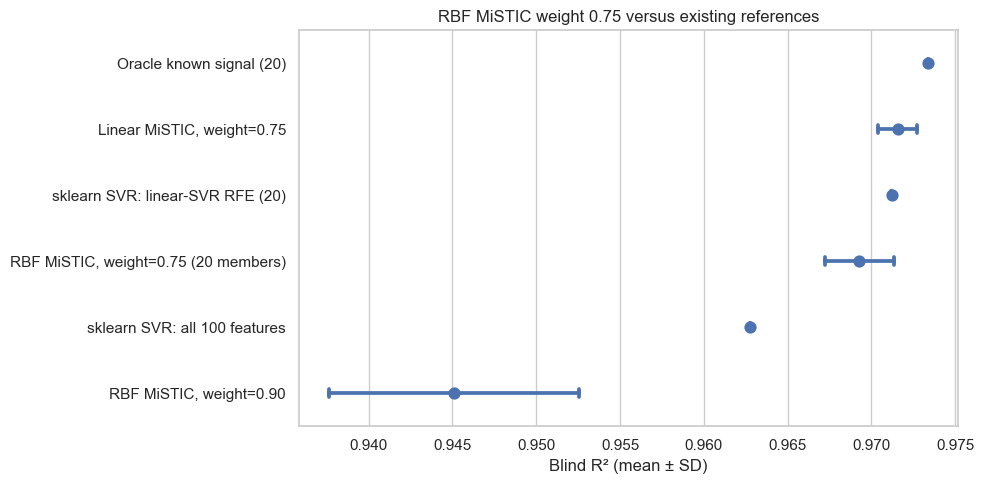

In [7]:
plot_frames = [results[["seed", "method", "r2"]]]
for label, frame in comparators.items():
    item = frame[["seed", "r2"]].copy()
    item["method"] = label
    plot_frames.append(item)
plot_data = pd.concat(plot_frames, ignore_index=True)
order = plot_data.groupby("method")["r2"].mean().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 5))
sns.pointplot(data=plot_data, y="method", x="r2", order=order,
              errorbar="sd", join=False, capsize=0.12, ax=ax)
ax.set_title("RBF MiSTIC weight 0.75 versus existing references")
ax.set_xlabel("Blind R² (mean ± SD)")
ax.set_ylabel("")
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_regression_rbf_rank075_20members_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation notes

All ten model-building seeds share the same blind observations. Paired results
therefore describe sensitivity to inner splitting and selection, not
uncertainty over independently sampled test sets.
